# **Baseline Comparison**

To evaluate the effectiveness of PsyFormer, we compared its performance against a diverse set of baseline machine-learning and deep-learning models, including Logistic Regression, Random Forest, XGBoost, SVM, MLP, CNN, RNN-based architectures, and Transformer-based models. All models were evaluated under the same leakage-free data partitioning and preprocessing settings to ensure a fair comparison. Macro-F1 was used as the primary comparison metric for both anxiety and depression severity assessment because it gives equal importance to all severity classes, including minority classes.

**Imports**

In [ ]:


import warnings
warnings.filterwarnings("ignore")

import copy
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, cohen_kappa_score, matthews_corrcoef
from sklearn.utils.class_weight import compute_class_weight

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except:
    HAS_LGBM = False


**Setup Configuration and Dataset Loading**

In [ ]:

DATA_PATH = "/content/Processed.csv"

SEED = 42
BATCH_SIZE = 32
TEST_BATCH_SIZE = 64
EPOCHS = 100
PATIENCE = 15
LR = 2e-4
TASK_WEIGHTS = (1.0, 1.1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# 2. Load Dataset

df = pd.read_csv(DATA_PATH)
data = df.copy()
data.columns = [c.strip() for c in data.columns]

print("Dataset shape:", data.shape)




Using device: cpu
Dataset shape: (2028, 39)


**Column Setup**

In [ ]:


pss_cols = [f"PSS{i}" for i in range(1, 11)]
gad_cols = [f"GAD{i}" for i in range(1, 8)]
phq_cols = [f"PHQ{i}" for i in range(1, 10)]

symptom_cols = pss_cols + gad_cols + phq_cols

demographic_cols = [
    "Age",
    "Gender",
    "University",
    "Department",
    "Academic_Year",
    "Current_CGPA",
    "waiver_or_scholarship"
]

target_label_cols = ["Anxiety Label", "Depression Label"]
target_num_cols = ["Anxiety_Target", "Depression_Target"]

explicit_leakage_cols = [
    "Stress Value", "Stress Label", "Stress_Target",
    "Anxiety Value", "Anxiety Label", "Anxiety_Target",
    "Depression Value", "Depression Label", "Depression_Target",
    "Joint_Target"
]


**Target Mapping**

In [ ]:


def clean_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip()


def map_anxiety_label(x):
    x = str(x).strip().lower()
    if x == "minimal anxiety":
        return 0
    elif x == "mild anxiety":
        return 1
    elif x == "moderate anxiety":
        return 2
    elif x == "severe anxiety":
        return 3
    return np.nan


def map_depression_label(x):
    x = str(x).strip().lower()
    if x in ["no depression", "minimal depression"]:
        return 0
    elif x == "mild depression":
        return 1
    elif x == "moderate depression":
        return 2
    elif x in ["moderately severe depression", "severe depression"]:
        return 3
    return np.nan


for col in demographic_cols + target_label_cols:
    data[col] = data[col].apply(clean_text)

data["Anxiety_Target"] = data["Anxiety Label"].apply(map_anxiety_label)
data["Depression_Target"] = data["Depression Label"].apply(map_depression_label)

data = data.dropna(subset=target_num_cols).reset_index(drop=True)
data["Anxiety_Target"] = data["Anxiety_Target"].astype(int)
data["Depression_Target"] = data["Depression_Target"].astype(int)

data["Joint_Target"] = (
    data["Anxiety_Target"].astype(str) + "_" +
    data["Depression_Target"].astype(str)
)

print("\nAnxiety distribution:")
print(data["Anxiety_Target"].value_counts().sort_index())

print("\nDepression distribution:")
print(data["Depression_Target"].value_counts().sort_index())




Anxiety distribution:
Anxiety_Target
0    159
1    505
2    620
3    744
Name: count, dtype: int64

Depression distribution:
Depression_Target
0     141
1     414
2     457
3    1016
Name: count, dtype: int64


**Safe Feature Setup**

In [ ]:


feature_cols = symptom_cols + demographic_cols
feature_cols = [c for c in feature_cols if c not in explicit_leakage_cols]

print("\nTotal feature columns:", len(feature_cols))
print("Explicit leakage columns inside features:",
      [c for c in feature_cols if c in explicit_leakage_cols])


# Remove exact duplicate rows before splitting
before = data.shape[0]
data = data.drop_duplicates(subset=feature_cols + target_num_cols).reset_index(drop=True)
after = data.shape[0]

print("Removed duplicate rows:", before - after)
print("Shape after duplicate removal:", data.shape)




Total feature columns: 33
Explicit leakage columns inside features: []
Removed duplicate rows: 6
Shape after duplicate removal: (2022, 42)


**Metrics**

In [ ]:


def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mae": mean_absolute_error(y_true, y_pred),
        "qwk": quadratic_weighted_kappa(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }


def ordinal_encoding(label, num_classes=4):
    return torch.tensor(
        [1.0 if label > k else 0.0 for k in range(num_classes - 1)],
        dtype=torch.float
    )


def logits_to_class(logits):
    probs = torch.sigmoid(logits)
    preds = torch.sum(probs, dim=1).round().long()
    return torch.clamp(preds, 0, 3)


def get_class_weights(y_array):
    classes = np.unique(y_array)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_array
    )
    return {int(c): float(w) for c, w in zip(classes, weights)}


def weighted_coral_loss(logits, ordinal_targets, class_labels, class_weight_dict):
    bce = F.binary_cross_entropy_with_logits(
        logits,
        ordinal_targets,
        reduction="none"
    )
    sample_loss = bce.mean(dim=1)

    weights = torch.tensor(
        [class_weight_dict[int(c.item())] for c in class_labels],
        dtype=torch.float,
        device=logits.device
    )

    return (sample_loss * weights).mean()



**Train / Validation / Test Split**

In [ ]:

indices = np.arange(len(data))
joint_labels = data[["Anxiety_Target", "Depression_Target"]].astype(str).agg("_".join, axis=1)

if joint_labels.value_counts().min() >= 2:
    stratify_key = joint_labels
else:
    stratify_key = data["Anxiety_Target"]

train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=stratify_key
)

train_val_df = data.iloc[train_val_idx].reset_index(drop=True)
test_df = data.iloc[test_idx].reset_index(drop=True)

train_val_joint = train_val_df[["Anxiety_Target", "Depression_Target"]].astype(str).agg("_".join, axis=1)

if train_val_joint.value_counts().min() >= 2:
    train_val_stratify = train_val_joint
else:
    train_val_stratify = train_val_df["Anxiety_Target"]

train_idx, val_idx = train_test_split(
    np.arange(len(train_val_df)),
    test_size=0.20,
    random_state=SEED,
    stratify=train_val_stratify
)

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print("\nTrain:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)


def detect_overlap(df1, df2, cols):
    h1 = pd.util.hash_pandas_object(df1[cols], index=False)
    h2 = pd.util.hash_pandas_object(df2[cols], index=False)
    return len(set(h1).intersection(set(h2)))


print("Train-Val overlap:", detect_overlap(train_df, val_df, feature_cols))
print("Train-Test overlap:", detect_overlap(train_df, test_df, feature_cols))




Train: (1293, 42)
Val  : (324, 42)
Test : (405, 42)
Train-Val overlap: 0
Train-Test overlap: 0


**Preprocessing and Fit only training setup**

In [ ]:


def preprocess_splits(train_df, val_df, test_df):
    try:
        pd.to_numeric(train_df["Age"], errors="raise")
        age_as_numeric = True
    except:
        age_as_numeric = False

    if age_as_numeric:
        categorical_demo_cols = [
            "Gender", "University", "Department",
            "Academic_Year", "waiver_or_scholarship"
        ]
        numeric_demo_cols = ["Age", "Current_CGPA"]
    else:
        categorical_demo_cols = [
            "Age", "Gender", "University", "Department",
            "Academic_Year", "waiver_or_scholarship"
        ]
        numeric_demo_cols = ["Current_CGPA"]

    X_train = train_df[symptom_cols + demographic_cols].copy()
    X_val = val_df[symptom_cols + demographic_cols].copy()
    X_test = test_df[symptom_cols + demographic_cols].copy()

    for col in categorical_demo_cols:
        for X in [X_train, X_val, X_test]:
            X[col] = X[col].astype(str).str.strip().replace(
                ["nan", "None", "", "NaN"], "Unknown"
            )

    for col in symptom_cols + numeric_demo_cols:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        X_val[col] = pd.to_numeric(X_val[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

    symptom_imputer = SimpleImputer(strategy="median")
    X_train_symptom = symptom_imputer.fit_transform(X_train[symptom_cols])
    X_val_symptom = symptom_imputer.transform(X_val[symptom_cols])
    X_test_symptom = symptom_imputer.transform(X_test[symptom_cols])

    symptom_scaler = StandardScaler()
    X_train_symptom = symptom_scaler.fit_transform(X_train_symptom)
    X_val_symptom = symptom_scaler.transform(X_val_symptom)
    X_test_symptom = symptom_scaler.transform(X_test_symptom)

    label_encoders = {}

    for col in categorical_demo_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))

        known = set(le.classes_)
        fallback = le.classes_[0]

        X_val[col] = X_val[col].apply(lambda x: x if x in known else fallback)
        X_test[col] = X_test[col].apply(lambda x: x if x in known else fallback)

        X_val[col] = le.transform(X_val[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))

        label_encoders[col] = le

    demo_cols = numeric_demo_cols + categorical_demo_cols

    demo_imputer = SimpleImputer(strategy="median")
    X_train_demo = demo_imputer.fit_transform(X_train[demo_cols])
    X_val_demo = demo_imputer.transform(X_val[demo_cols])
    X_test_demo = demo_imputer.transform(X_test[demo_cols])

    demo_scaler = StandardScaler()
    X_train_demo = demo_scaler.fit_transform(X_train_demo)
    X_val_demo = demo_scaler.transform(X_val_demo)
    X_test_demo = demo_scaler.transform(X_test_demo)

    return (
        X_train_symptom, X_val_symptom, X_test_symptom,
        X_train_demo, X_val_demo, X_test_demo,
        demo_cols
    )


(
    X_train_symptom, X_val_symptom, X_test_symptom,
    X_train_demo, X_val_demo, X_test_demo,
    demo_cols
) = preprocess_splits(train_df, val_df, test_df)

X_train_flat = np.concatenate([X_train_symptom, X_train_demo], axis=1)
X_val_flat = np.concatenate([X_val_symptom, X_val_demo], axis=1)
X_test_flat = np.concatenate([X_test_symptom, X_test_demo], axis=1)

y_train_anx = train_df["Anxiety_Target"].values
y_val_anx = val_df["Anxiety_Target"].values
y_test_anx = test_df["Anxiety_Target"].values

y_train_dep = train_df["Depression_Target"].values
y_val_dep = val_df["Depression_Target"].values
y_test_dep = test_df["Depression_Target"].values

anx_class_weights = get_class_weights(y_train_anx)
dep_class_weights = get_class_weights(y_train_dep)


**Dataset Preparation**

In [ ]:


class MultiTaskTabularDataset(Dataset):
    def __init__(self, X_symptom, X_demo, y_anx, y_dep):
        self.X_symptom = torch.tensor(X_symptom, dtype=torch.float)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float)
        self.y_anx = torch.tensor(y_anx, dtype=torch.long)
        self.y_dep = torch.tensor(y_dep, dtype=torch.long)

    def __len__(self):
        return len(self.X_symptom)

    def __getitem__(self, idx):
        return {
            "x_symptom": self.X_symptom[idx],
            "x_demo": self.X_demo[idx],
            "y_anx": self.y_anx[idx],
            "y_dep": self.y_dep[idx],
            "y_anx_ord": ordinal_encoding(int(self.y_anx[idx].item()), 4),
            "y_dep_ord": ordinal_encoding(int(self.y_dep[idx].item()), 4)
        }


train_dataset = MultiTaskTabularDataset(X_train_symptom, X_train_demo, y_train_anx, y_train_dep)
val_dataset = MultiTaskTabularDataset(X_val_symptom, X_val_demo, y_val_anx, y_val_dep)
test_dataset = MultiTaskTabularDataset(X_test_symptom, X_test_demo, y_test_anx, y_test_dep)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)




**Result Table**

In [ ]:


comparison_rows = []

def add_result(model_name, task_name, metrics):
    comparison_rows.append({
        "Model": model_name,
        "Task": task_name,
        "Accuracy": round(metrics["accuracy"], 4),
        "Precision": round(metrics["precision"], 4),
        "Recall": round(metrics["recall"], 4),
        "Macro-F1": round(metrics["macro_f1"], 4),
        "MAE": round(metrics["mae"], 4),
        "QWK": round(metrics["qwk"], 4),
        "MCC": round(metrics["mcc"], 4)
    })


# **Classical ML Models**

In [ ]:


classical_models = {
    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED
    ),


    "Ridge Classifier": RidgeClassifier(
        class_weight="balanced",
        random_state=SEED
    ),


    "RBF SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=False,
        random_state=SEED
    ),

    "Polynomial SVM": SVC(
        kernel="poly",
        degree=3,
        class_weight="balanced",
        probability=False,
        random_state=SEED
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=SEED
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        random_state=SEED
    )
}

if HAS_XGB:
    classical_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softmax",
        num_class=4,
        eval_metric="mlogloss",
        random_state=SEED
    )

if HAS_LGBM:
    classical_models["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=SEED
    )


for model_name, model in classical_models.items():
    print("\nTraining:", model_name)

    model_anx = copy.deepcopy(model)
    model_dep = copy.deepcopy(model)

    model_anx.fit(X_train_flat, y_train_anx)
    model_dep.fit(X_train_flat, y_train_dep)

    pred_anx = model_anx.predict(X_test_flat)
    pred_dep = model_dep.predict(X_test_flat)

    add_result(model_name, "Anxiety", compute_metrics(y_test_anx, pred_anx))
    add_result(model_name, "Depression", compute_metrics(y_test_dep, pred_dep))





Training: Naive Bayes

Training: KNN

Training: Logistic Regression

Training: Ridge Classifier

Training: RBF SVM

Training: Polynomial SVM

Training: Decision Tree

Training: Random Forest

Training: Gradient Boosting

Training: AdaBoost

Training: XGBoost

Training: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000603 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 185
[LightGBM] [Info] Number of data points in the train set: 1293, number of used features: 32
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

# **Deep Learning Training Helpers**

In [ ]:


def evaluate_multitask_model(model, loader):
    model.eval()

    anx_true, anx_pred = [], []
    dep_true, dep_pred = [], []

    with torch.no_grad():
        for batch in loader:
            x_symptom = batch["x_symptom"].to(device)
            x_demo = batch["x_demo"].to(device)
            y_anx = batch["y_anx"].to(device)
            y_dep = batch["y_dep"].to(device)

            anx_logits, dep_logits = model(x_symptom, x_demo)

            pred_anx = logits_to_class(anx_logits)
            pred_dep = logits_to_class(dep_logits)

            anx_true.extend(y_anx.cpu().numpy())
            anx_pred.extend(pred_anx.cpu().numpy())

            dep_true.extend(y_dep.cpu().numpy())
            dep_pred.extend(pred_dep.cpu().numpy())

    return {
        "anxiety": compute_metrics(anx_true, anx_pred),
        "depression": compute_metrics(dep_true, dep_pred)
    }


def train_deep_model(
    model,
    train_loader,
    val_loader,
    anx_class_weights,
    dep_class_weights,
    epochs=EPOCHS,
    lr=LR,
    task_weights=TASK_WEIGHTS,
    patience=PATIENCE
):
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5
    )

    best_state = None
    best_score = -1
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()

        for batch in train_loader:
            x_symptom = batch["x_symptom"].to(device)
            x_demo = batch["x_demo"].to(device)
            y_anx = batch["y_anx"].to(device)
            y_dep = batch["y_dep"].to(device)
            y_anx_ord = batch["y_anx_ord"].to(device)
            y_dep_ord = batch["y_dep_ord"].to(device)

            optimizer.zero_grad()

            anx_logits, dep_logits = model(x_symptom, x_demo)

            loss_anx = weighted_coral_loss(
                anx_logits,
                y_anx_ord,
                y_anx,
                anx_class_weights
            )

            loss_dep = weighted_coral_loss(
                dep_logits,
                y_dep_ord,
                y_dep,
                dep_class_weights
            )

            loss = task_weights[0] * loss_anx + task_weights[1] * loss_dep
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        val_results = evaluate_multitask_model(model, val_loader)
        val_avg_f1 = (
            val_results["anxiety"]["macro_f1"] +
            val_results["depression"]["macro_f1"]
        ) / 2.0

        scheduler.step(val_avg_f1)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Val Avg Macro-F1: {val_avg_f1:.4f}")

        if val_avg_f1 > best_score:
            best_score = val_avg_f1
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

**Models**

In [ ]:


class MultiTaskMLP(nn.Module):
    def __init__(self, symptom_dim, demo_dim, hidden_dim=128, dropout=0.35):
        super().__init__()

        self.symptom_mlp = nn.Sequential(
            nn.Linear(symptom_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.GELU()
        )

        self.demo_mlp = nn.Sequential(
            nn.Linear(demo_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.GELU()
        )

        shared_dim = 64 + 16

        self.anx_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

        self.dep_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_symptom, x_demo):
        sym = self.symptom_mlp(x_symptom)
        demo = self.demo_mlp(x_demo)
        shared = torch.cat([sym, demo], dim=1)
        return self.anx_head(shared), self.dep_head(shared)


class MultiTaskDNN(nn.Module):
    def __init__(self, symptom_dim, demo_dim, dropout=0.35):
        super().__init__()

        input_dim = symptom_dim + demo_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU()
        )

        self.anx_head = nn.Linear(64, 3)
        self.dep_head = nn.Linear(64, 3)

    def forward(self, x_symptom, x_demo):
        x = torch.cat([x_symptom, x_demo], dim=1)
        h = self.net(x)
        return self.anx_head(h), self.dep_head(h)


class MultiTaskCNN(nn.Module):
    def __init__(self, seq_len, demo_dim, dropout=0.35):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)

        self.dropout = nn.Dropout(dropout)
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.demo_mlp = nn.Sequential(
            nn.Linear(demo_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.GELU()
        )

        shared_dim = 64 + 16

        self.anx_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

        self.dep_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_symptom, x_demo):
        x = x_symptom.unsqueeze(1)
        x = self.dropout(F.gelu(self.bn1(self.conv1(x))))
        x = self.dropout(F.gelu(self.bn2(self.conv2(x))))
        x = self.pool(x).squeeze(-1)

        demo = self.demo_mlp(x_demo)
        shared = torch.cat([x, demo], dim=1)

        return self.anx_head(shared), self.dep_head(shared)


class MultiTaskLSTM(nn.Module):
    def __init__(self, demo_dim, hidden_dim=64, dropout=0.35, bidirectional=False):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )

        lstm_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.demo_mlp = nn.Sequential(
            nn.Linear(demo_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.GELU()
        )

        shared_dim = lstm_dim + 16

        self.anx_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

        self.dep_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_symptom, x_demo):
        x = x_symptom.unsqueeze(-1)
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        demo = self.demo_mlp(x_demo)
        shared = torch.cat([h, demo], dim=1)
        return self.anx_head(shared), self.dep_head(shared)


class MultiTaskGRU(nn.Module):
    def __init__(self, demo_dim, hidden_dim=64, dropout=0.35):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.demo_mlp = nn.Sequential(
            nn.Linear(demo_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.GELU()
        )

        shared_dim = hidden_dim + 16

        self.anx_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

        self.dep_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_symptom, x_demo):
        x = x_symptom.unsqueeze(-1)
        _, h = self.gru(x)
        h = h[-1]
        demo = self.demo_mlp(x_demo)
        shared = torch.cat([h, demo], dim=1)
        return self.anx_head(shared), self.dep_head(shared)


class MultiTaskCNNLSTM(nn.Module):
    def __init__(self, demo_dim, cnn_channels=64, hidden_dim=64, dropout=0.35):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(1, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.demo_mlp = nn.Sequential(
            nn.Linear(demo_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.GELU()
        )

        shared_dim = hidden_dim + 16

        self.anx_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

        self.dep_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_symptom, x_demo):
        x = x_symptom.unsqueeze(1)
        x = self.cnn(x).transpose(1, 2)
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        demo = self.demo_mlp(x_demo)
        shared = torch.cat([h, demo], dim=1)
        return self.anx_head(shared), self.dep_head(shared)


class MultiTaskTransformer(nn.Module):
    def __init__(self, seq_len, demo_dim, d_model=64, nhead=4, num_layers=2, dropout=0.35):
        super().__init__()

        self.input_proj = nn.Linear(1, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.demo_mlp = nn.Sequential(
            nn.Linear(demo_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.GELU()
        )

        shared_dim = d_model + 16

        self.anx_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

        self.dep_head = nn.Sequential(
            nn.Linear(shared_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_symptom, x_demo):
        x = x_symptom.unsqueeze(-1)
        x = self.input_proj(x)
        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.transformer(x)
        x = x.mean(dim=1)

        demo = self.demo_mlp(x_demo)
        shared = torch.cat([x, demo], dim=1)

        return self.anx_head(shared), self.dep_head(shared)


In [ ]:
class HybridCNNRNNTransformer(nn.Module):
    def __init__(
        self,
        seq_len,
        demo_dim,
        rnn_type="bigru",
        cnn_channels=64,
        rnn_hidden=64,
        attn_heads=4,
        transformer_layers=2,
        decoder_layers=1,
        dropout=0.4
    ):
        super().__init__()

        self.rnn_type = rnn_type.lower()

        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Conv1d(32, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        bidirectional = self.rnn_type in ["bilstm", "bigru"]

        if self.rnn_type in ["lstm", "bilstm"]:
            self.rnn = nn.LSTM(
                input_size=cnn_channels,
                hidden_size=rnn_hidden,
                batch_first=True,
                bidirectional=bidirectional
            )
        elif self.rnn_type in ["gru", "bigru"]:
            self.rnn = nn.GRU(
                input_size=cnn_channels,
                hidden_size=rnn_hidden,
                batch_first=True,
                bidirectional=bidirectional
            )
        else:
            raise ValueError("Invalid rnn_type.")

        rnn_out_dim = rnn_hidden * 2 if bidirectional else rnn_hidden

        self.self_attn = nn.MultiheadAttention(
            embed_dim=rnn_out_dim,
            num_heads=attn_heads,
            dropout=dropout,
            batch_first=True
        )

        self.attn_norm = nn.LayerNorm(rnn_out_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=rnn_out_dim,
            nhead=attn_heads,
            dim_feedforward=rnn_out_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=transformer_layers
        )

        self.task_queries = nn.Parameter(torch.randn(2, rnn_out_dim))

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=rnn_out_dim,
            nhead=attn_heads,
            dim_feedforward=rnn_out_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=decoder_layers
        )

        self.demo_mlp = nn.Sequential(
            nn.Linear(demo_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.GELU()
        )

        head_input_dim = rnn_out_dim + 16

        self.anx_head = nn.Sequential(
            nn.Linear(head_input_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

        self.dep_head = nn.Sequential(
            nn.Linear(head_input_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_symptom, x_demo):
        x = x_symptom.unsqueeze(1)
        x = self.cnn(x)
        x = x.transpose(1, 2)

        x, _ = self.rnn(x)

        attn_out, _ = self.self_attn(x, x, x)
        x = self.attn_norm(x + attn_out)

        memory = self.transformer_encoder(x)

        B = memory.size(0)
        queries = self.task_queries.unsqueeze(0).repeat(B, 1, 1)

        decoded = self.transformer_decoder(tgt=queries, memory=memory)

        anxiety_repr = decoded[:, 0, :]
        depression_repr = decoded[:, 1, :]

        demo_repr = self.demo_mlp(x_demo)

        anxiety_final = torch.cat([anxiety_repr, demo_repr], dim=1)
        depression_final = torch.cat([depression_repr, demo_repr], dim=1)

        return self.anx_head(anxiety_final), self.dep_head(depression_final)




**Run Deep Models**

In [ ]:


def run_deep_experiment(model_name, model, lr=LR):
    print("\n" + "=" * 80)
    print("Training:", model_name)
    print("=" * 80)

    set_seed(SEED)

    model = train_deep_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        anx_class_weights=anx_class_weights,
        dep_class_weights=dep_class_weights,
        epochs=EPOCHS,
        lr=lr,
        task_weights=TASK_WEIGHTS,
        patience=PATIENCE
    )

    test_results = evaluate_multitask_model(model, test_loader)

    add_result(model_name, "Anxiety", test_results["anxiety"])
    add_result(model_name, "Depression", test_results["depression"])

    print("Anxiety:", test_results["anxiety"])
    print("Depression:", test_results["depression"])

    return model, test_results


symptom_dim = X_train_symptom.shape[1]
demo_dim = X_train_demo.shape[1]

deep_experiments = [
    (
        "MLP",
        MultiTaskMLP(symptom_dim, demo_dim, hidden_dim=128, dropout=0.35),
        2e-4
    ),
    (
        "DNN",
        MultiTaskDNN(symptom_dim, demo_dim, dropout=0.35),
        2e-4
    ),
    (
        "CNN",
        MultiTaskCNN(symptom_dim, demo_dim, dropout=0.35),
        2e-4
    ),
    (
        "LSTM",
        MultiTaskLSTM(demo_dim, hidden_dim=64, dropout=0.35, bidirectional=False),
        2e-4
    ),
    (
        "GRU",
        MultiTaskGRU(demo_dim, hidden_dim=64, dropout=0.35),
        2e-4
    ),
    (
        "BiLSTM",
        MultiTaskLSTM(demo_dim, hidden_dim=64, dropout=0.35, bidirectional=True),
        2e-4
    ),
    (
        "CNN-LSTM",
        MultiTaskCNNLSTM(demo_dim, cnn_channels=64, hidden_dim=64, dropout=0.35),
        2e-4
    ),
    (
        "Transformer Encoder",
        MultiTaskTransformer(symptom_dim, demo_dim, d_model=64, nhead=4, num_layers=2, dropout=0.35),
        2e-4
    ),
    (
        "Hybrid CNN+RNN+Transformer",
        HybridCNNRNNTransformer(
            seq_len=symptom_dim,
            demo_dim=demo_dim,
            rnn_type="bigru",
            cnn_channels=64,
            rnn_hidden=64,
            attn_heads=4,
            transformer_layers=2,
            decoder_layers=1,
            dropout=0.4
        ),
        2e-4
    )
]

for model_name, model, lr in deep_experiments:
    run_deep_experiment(model_name, model, lr=lr)




Training: MLP
Epoch 001 | Val Avg Macro-F1: 0.1322
Epoch 010 | Val Avg Macro-F1: 0.7981
Epoch 020 | Val Avg Macro-F1: 0.9128
Epoch 030 | Val Avg Macro-F1: 0.9569
Epoch 040 | Val Avg Macro-F1: 0.9538
Epoch 050 | Val Avg Macro-F1: 0.9488
Epoch 060 | Val Avg Macro-F1: 0.9476
Early stopping triggered.
Anxiety: {'accuracy': 0.9580246913580247, 'precision': 0.9251988881824554, 'recall': 0.9619832624064499, 'macro_f1': 0.9389800688898428, 'mae': 0.04197530864197531, 'qwk': np.float64(0.9781579039201566), 'cohen_kappa': np.float64(0.9408144142905036), 'mcc': np.float64(0.9416655411715071)}
Depression: {'accuracy': 0.9481481481481482, 'precision': 0.9030292345663872, 'recall': 0.9382676826957735, 'macro_f1': 0.9172844223835036, 'mae': 0.05185185185185185, 'qwk': np.float64(0.9743059898311537), 'cohen_kappa': np.float64(0.9211053598263483), 'mcc': np.float64(0.9215485576356444)}

Training: DNN
Epoch 001 | Val Avg Macro-F1: 0.2346
Epoch 010 | Val Avg Macro-F1: 0.8175
Epoch 020 | Val Avg Macro-F1

**Final Result Table**

In [ ]:


comparison_df = pd.DataFrame(comparison_rows)

comparison_df = comparison_df.sort_values(
    by=["Task", "Macro-F1"],
    ascending=[True, False]
).reset_index(drop=True)

print("\n" + "=" * 90)
print("FINAL LEAKAGE-FREE FAIR MODEL COMPARISON")
print("=" * 90)

print(comparison_df)

comparison_df.to_csv("leakage_free_fair_model_comparison.csv", index=False)

print("\nSaved file: leakage_free_fair_model_comparison.csv")



FINAL LEAKAGE-FREE FAIR MODEL COMPARISON
                         Model        Task  Accuracy  Precision  Recall  \
0          Transformer Encoder     Anxiety    0.9605     0.9432  0.9639   
1          Logistic Regression     Anxiety    0.9605     0.9390  0.9492   
2                          DNN     Anxiety    0.9605     0.9394  0.9472   
3                          MLP     Anxiety    0.9580     0.9252  0.9620   
4                      RBF SVM     Anxiety    0.9284     0.9176  0.9131   
5                Random Forest     Anxiety    0.9235     0.9201  0.8894   
6                      XGBoost     Anxiety    0.9210     0.9065  0.8926   
7                       BiLSTM     Anxiety    0.9062     0.8853  0.9033   
8   Hybrid CNN+RNN+Transformer     Anxiety    0.8963     0.8829  0.9086   
9            Gradient Boosting     Anxiety    0.9136     0.9000  0.8810   
10                    LightGBM     Anxiety    0.9062     0.8938  0.8824   
11                        LSTM     Anxiety    0.8938     0

**Final Result Plotting**

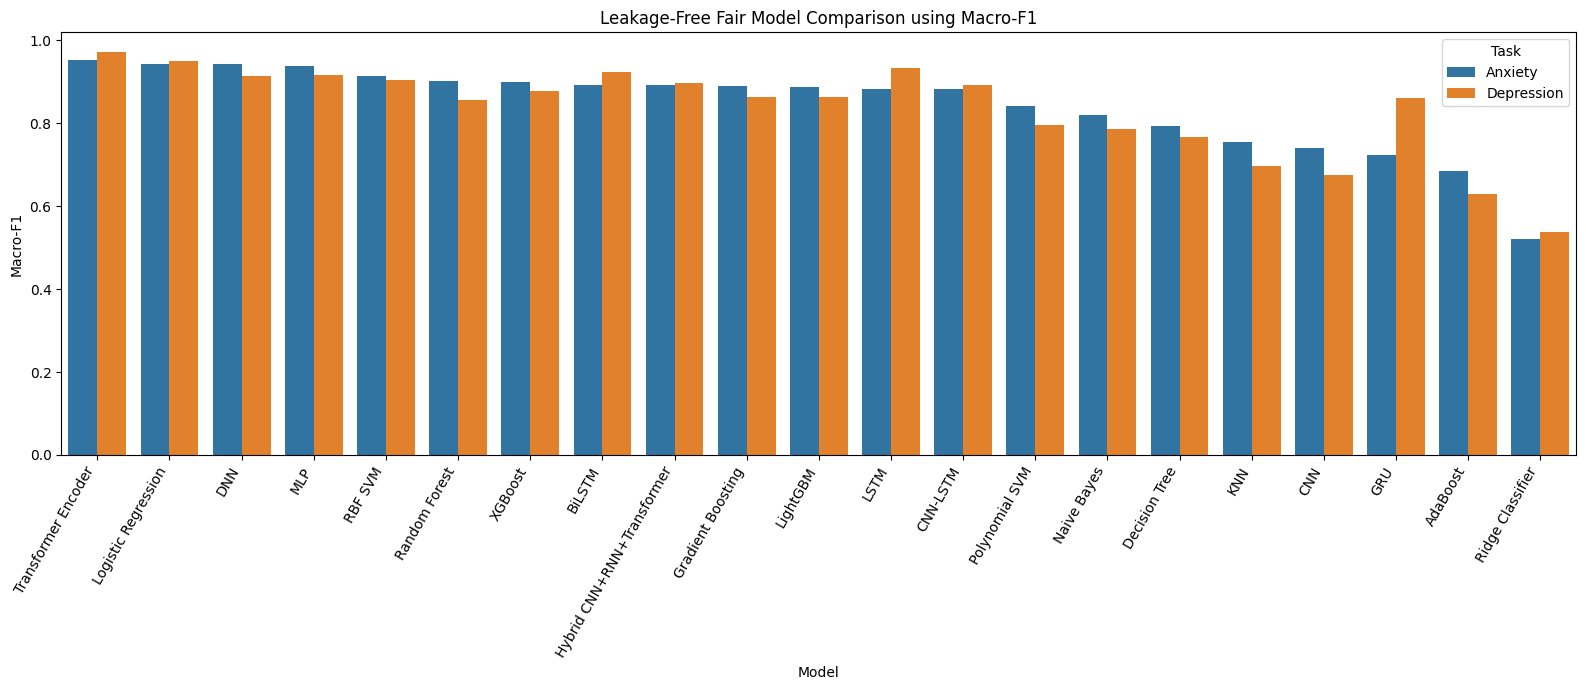

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 7))
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Macro-F1",
    hue="Task"
)

plt.xticks(rotation=60, ha="right")
plt.title("Leakage-Free Fair Model Comparison using Macro-F1")
plt.ylabel("Macro-F1")
plt.xlabel("Model")
plt.tight_layout()
plt.show()